In [3]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [6]:
# Reading the CSV
df = pd.read_csv('TRAIN.csv')

df.head()

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52


**Exploratory Data Analysis (EDA) **

In [10]:
print(df.shape)
print(df.dtypes)
print(df.info())
print(df.isnull().sum())
df.describe()

(188340, 10)
ID                object
Store_id           int64
Store_Type        object
Location_Type     object
Region_Code       object
Date              object
Holiday            int64
Discount          object
#Order             int64
Sales            float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188340 entries, 0 to 188339
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ID             188340 non-null  object 
 1   Store_id       188340 non-null  int64  
 2   Store_Type     188340 non-null  object 
 3   Location_Type  188340 non-null  object 
 4   Region_Code    188340 non-null  object 
 5   Date           188340 non-null  object 
 6   Holiday        188340 non-null  int64  
 7   Discount       188340 non-null  object 
 8   #Order         188340 non-null  int64  
 9   Sales          188340 non-null  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 14.4+ MB
None
ID  

,Store_id,Holiday,#Order,Sales
count,188340.000000,188340.000000,188340.000000,188340.000000
mean,183.000000,0.131783,68.205692,42784.327982
std,105.366308,0.338256,30.467415,18456.708302
min,1.000000,0.000000,0.000000,0.000000
25%,92.000000,0.000000,48.000000,30426.000000
50%,183.000000,0.000000,63.000000,39678.000000
75%,274.000000,0.000000,82.000000,51909.000000
max,365.000000,1.000000,371.000000,247215.000000


In [15]:
# Parsing and Formatting the Date
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['DayofWeek'] = df['Date'].dt.dayofweek
df['Year'] = df['Date'].dt.year

df.head()

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales,Month,DayofWeek,Year
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84,1,0,2018
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12,1,0,2018
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20,1,0,2018
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16,1,0,2018
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52,1,0,2018


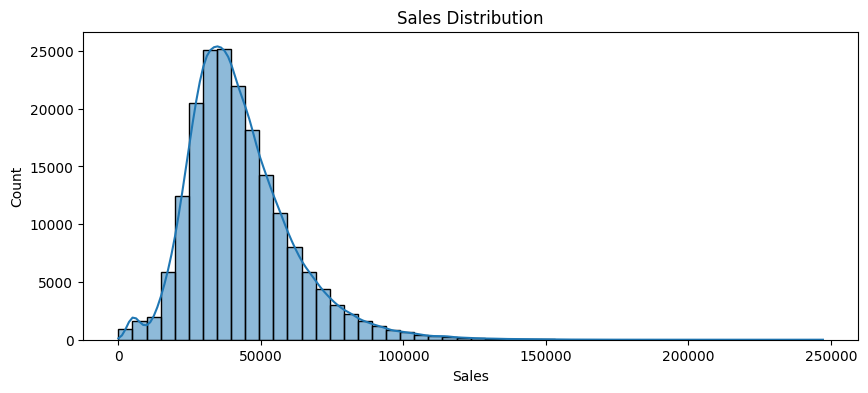

In [17]:
# Univariate : Sales Distribution
plt.figure(figsize=(10,4))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Sales Distribution')
plt.show()

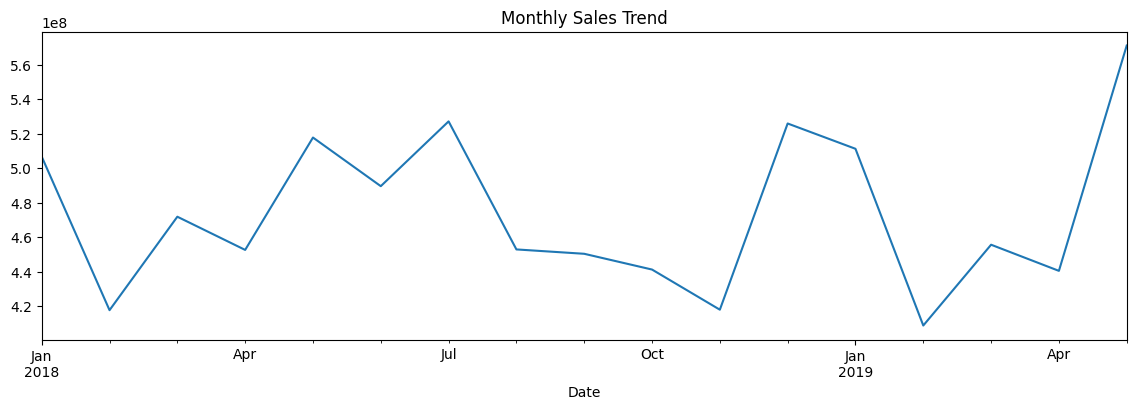

In [18]:
# Sales Over Time

monthly = df.groupby(df['Date'].dt.to_period('M'))['Sales'].sum()
monthly.plot(figsize=(14,4), title='Monthly Sales Trend')
plt.show()

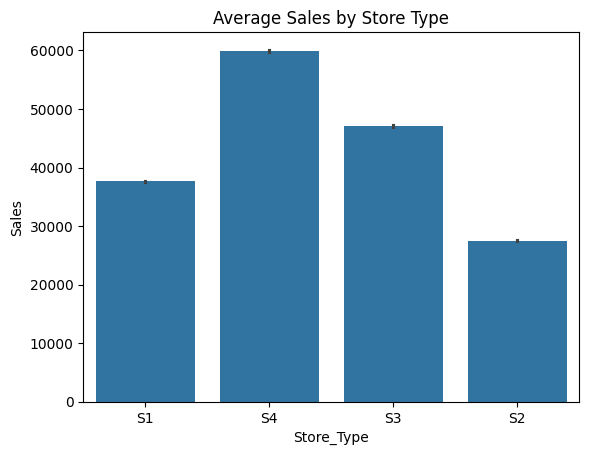

In [19]:
# Sales by Store Type

sns.barplot(data=df, x='Store_Type', y='Sales', estimator=np.mean)
plt.title('Average Sales by Store Type')
plt.show()

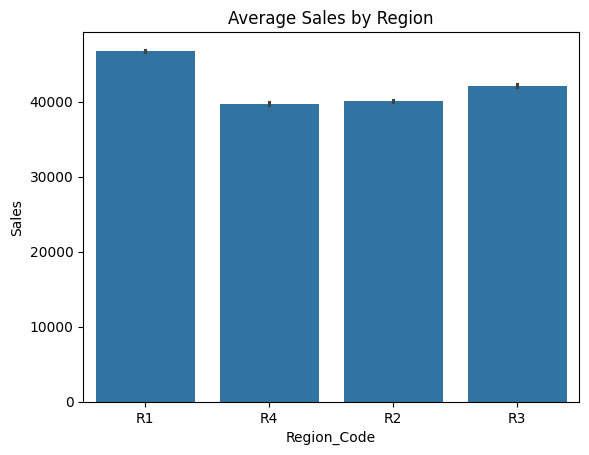

In [20]:
# Sales by Region


sns.barplot(data=df, x='Region_Code', y='Sales', estimator=np.mean)
plt.title('Average Sales by Region')
plt.show()

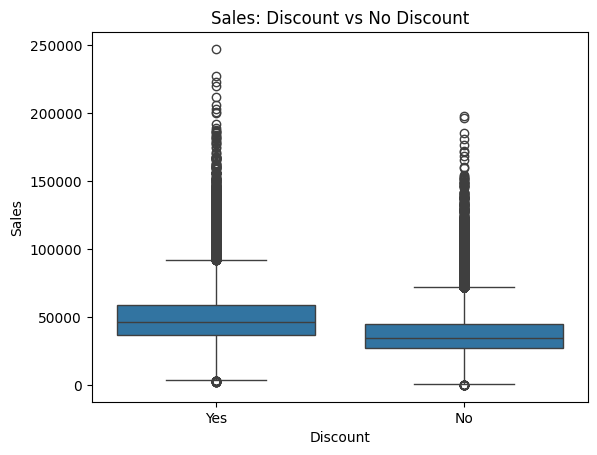

In [21]:
# Discount Impact
sns.boxplot(data=df, x='Discount', y='Sales')
plt.title('Sales: Discount vs No Discount')
plt.show()

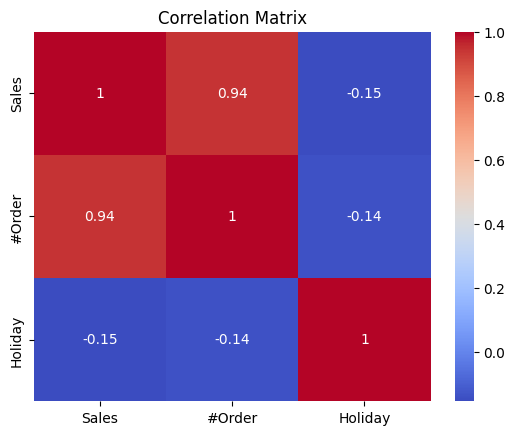

In [22]:
# Coorelation Heatmap

sns.heatmap(df[['Sales', '#Order', 'Holiday']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Hypothesis Testing**

In [27]:
# H1 : Discount Increases Sale
discount_yes = df[df['Discount'] == 'Yes']['Sales']
discount_no  = df[df['Discount'] == 'No']['Sales']

t_stat, p_val = stats.ttest_ind(discount_yes, discount_no)
print(f"Discount T-test: t={t_stat:.3f}, p={p_val:.3f}")

Discount T-test: t=148.579, p=0.000


As the p < 0.05 --> Reject Null Hypothesis --> Discount significantly affects the sale.

In [29]:
# H2 : Holiday Sales Increase

holiday_sales     = df[df['Holiday'] == 1]['Sales']
non_holiday_sales = df[df['Holiday'] == 0]['Sales']

t_stat2, p_val2 = stats.ttest_ind(holiday_sales, non_holiday_sales)
print(f"Holiday T-test: t={t_stat2:.3f}, p={p_val2:.4f}")

Holiday T-test: t=-67.990, p=0.0000


With p < 0.05, we reject Null Hypothesis --> Holidays has Increased the Sales.

In [30]:
# H3 : Store Type affects Sales (ANOVA)
groups = [group['Sales'].values for _, group in df.groupby('Store_Type')]
f_stat, p_val3 = stats.f_oneway(*groups)
print(f"Store Type ANOVA: F={f_stat:.3f}, p={p_val3:.4f}")

Store Type ANOVA: F=35123.644, p=0.0000


In [31]:
# H4 : Regional Variability (Kruskal-Wallis)

regions = [group['Sales'].values for _, group in df.groupby('Region_Code')]
h_stat, p_val4 = stats.kruskal(*regions)
print(f"Regional Kruskal-Wallis: H={h_stat:.3f}, p={p_val4:.4f}")


Regional Kruskal-Wallis: H=3968.064, p=0.0000


In [32]:
# H5 : Orders vs Sales Correlation

corr, p_val5 = stats.pearsonr(df['#Order'], df['Sales'])
print(f"Pearson Correlation (Orders vs Sales): r={corr:.3f}, p={p_val5:.4f}")

Pearson Correlation (Orders vs Sales): r=0.942, p=0.0000


**MACHINE LEARNING MODEL **


Model: Linear Regression
MAE:  4142.20
RMSE: 5573.66
MAPE: inf%

Model: Random Forest
MAE:  2277.20
RMSE: 3466.81
MAPE: 5.28%

Model: XGBoost
MAE:  2137.26
RMSE: 3373.49
MAPE: inf%
               Model          MAE         RMSE      MAPE
2            XGBoost  2137.260198  3373.485989       inf
1      Random Forest  2277.195711  3466.805682  5.283184
0  Linear Regression  4142.204647  5573.655092       inf


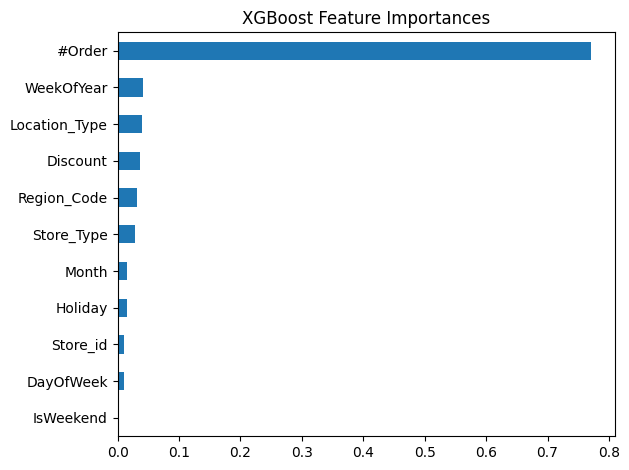

In [34]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ===== FEATURE ENGINEERING =====
df['Date'] = pd.to_datetime(df['Date'])
df['Month']      = df['Date'].dt.month
df['DayOfWeek']  = df['Date'].dt.dayofweek
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)

# Encode categoricals
le = LabelEncoder()
for col in ['Store_Type', 'Location_Type', 'Region_Code', 'Discount']:
    df[col] = le.fit_transform(df[col].astype(str))

# ===== DEFINE FEATURES & TARGET =====
features = ['Store_id', 'Store_Type', 'Location_Type', 'Region_Code',
            'Holiday', 'Discount', '#Order', 'Month', 'DayOfWeek',
            'WeekOfYear', 'IsWeekend']
target = 'Sales'

X = df[features]
y = df[target]

# ===== TRAIN/TEST SPLIT =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False  # Time-aware split
)

# ===== EVALUATION FUNCTION =====
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = []

# ===== MODEL 1: Baseline — Linear Regression =====
lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate("Linear Regression", y_test, lr.predict(X_test)))

# ===== MODEL 2: Random Forest =====
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate("Random Forest", y_test, rf.predict(X_test)))

# ===== MODEL 3: XGBoost (usually best) =====
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05,
                   max_depth=6, random_state=42)
xgb.fit(X_train, y_train)
results.append(evaluate("XGBoost", y_test, xgb.predict(X_test)))

# ===== COMPARE RESULTS =====
results_df = pd.DataFrame(results).sort_values('RMSE')
print(results_df)

# ===== FEATURE IMPORTANCE =====
importances = pd.Series(xgb.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', title='XGBoost Feature Importances')
plt.tight_layout()
plt.show()

In [38]:
import joblib
import os
os.makedirs('deployment', exist_ok=True)

# Save the best model
joblib.dump(xgb, 'deployment/model.pkl')
print("Model saved!")

Model saved!
